# Building Quantum Circuits: From Basic Gates to Multi-Qubit Circuits

In this notebook, we will build and investigate small quantum circuits using the gates and concepts you have already learned.

### What you already know

- Qubits and computational-basis states
- Single-qubit gates such as **X, Z, and H**
- Basic two-qubit gates such as **CNOT, CZ, and SWAP**
- Creating a `QuantumCircuit` in Qiskit
- Using a statevector to check a circuit

Rather than studying gates individually, we will focus on how different quantum gates are combined to construct useful quantum circuits.

### Our working method

For almost every exercise:

> **Predict → Implement → Visualize → Check → Explain**

**Important:** Try to make your prediction *before* running the code.


## A very short recap

You will use these gates repeatedly:

| Gate | Qiskit | Main action |
|:---:|:---|:---|
| **X** | `qc.x(q)` | Bit flip: $|0\rangle \leftrightarrow |1\rangle$ |
| **Y** | `qc.y(q)` | Bit + phase transformation |
| **Z** | `qc.z(q)` | Phase flip: $|1\rangle \rightarrow -|1\rangle$ |
| **H** | `qc.h(q)` | Creates/undoes superposition |
| **S** | `qc.s(q)` | Phase rotation |
| **T** | `qc.t(q)` | Smaller phase rotation |


For the controlled gates in this notebook, remember:

```text
control ──●──
          │
target  ──U──
```

The control determines **whether** the operation on the target is applied.


In [1]:
!pip install -q qiskit pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.1 MB/s eta 0:00:00


## Setup

Run the following cell before starting the exercises.

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)

print("Qiskit setup complete.")

Qiskit setup complete.


## 1. Getting started with Quantum circuits

Exercise 1 — A quantum circuit is simply a sequence of operations applied to qubits.

Let's create our first circuit.

```text
q0 ──X──H──
```

means:

1. Start with the qubit in $|0\rangle$.
2. Apply X.
3. Apply H.


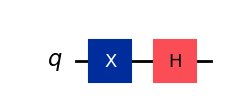

Statevector:
Statevector([ 0.7071+0.j, -0.7071+0.j],
            dims=(2,))


In [3]:
qc = QuantumCircuit(1)

qc.x(0)
qc.h(0)

display(qc.draw("mpl"))

print("Statevector:")
print(Statevector(qc))


## Exercise 2 —  Let's create another circuit.

```text
q0 ──H──X──
```

means:

1. Start with the qubit in $|0\rangle$.
2. Apply H.
3. Apply X.

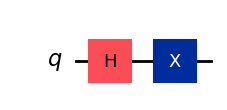

Statevector:
Statevector([0.7071+0.j, 0.7071+0.j],
            dims=(2,))


In [4]:
qc = QuantumCircuit(1)

qc.h(0)
qc.x(0)

display(qc.draw("mpl"))

print("Statevector:")
print(Statevector(qc))

### Observation

The two circuits contain the **same two gates**, but the order is different.

This can change the final state.

> In a quantum circuit, the order in which gates are applied matters.

# Exercise 3: Combining two gates

Combine two operations.

```text
q0 ──X────X──
```

Starting from $|0\rangle$:

1. Apply X.
2. Apply X again.
3. Predict the final state, check your answer with Qiskit.

What do you notice?

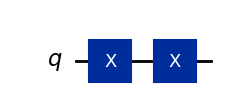

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [5]:
qc = QuantumCircuit(1)

# Apply X twice
qc.x(0)
qc.x(0)
display(qc.draw("mpl"))
print(Statevector(qc))


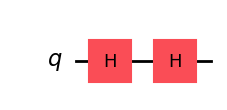

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [6]:
qc = QuantumCircuit(1)

# Apply X twice
qc.h(0)
qc.h(0)
display(qc.draw("mpl"))
print(Statevector(qc))


### Observation: Some gates can undo themselves

We have seen that

$X^2=I$

and

$H^2=I$

This means that applying X or H twice brings the quantum state back to
where it started.

Several commonly used gates have this property, including X, Y, Z, H,
CNOT, CZ, SWAP, and Toffoli.

These are called **self-inverse gates**.

For example,

$S^2=Z\neq I$

so not every quantum gate is self-inverse.

### A useful idea: reversibility

Quantum gates are **unitary**, which means quantum operations are
reversible.

### Key idea

> **Self-inverse → the same gate reverses itself**

This property is useful when **building, reversing, and simplifying
quantum circuits**.

# 2. Building a simple two-qubit circuit

We now move from one qubit to **two qubits**.

We start with both qubits in the state. Start with $|00\rangle$:

Apply X to the first qubit:

$
|00\rangle \rightarrow |10\rangle$

This changes the state of `q0` while leaving `q1` unchanged.

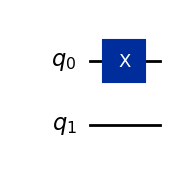

Statevector:
Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [7]:
qc = QuantumCircuit(2)

# Apply X to q0
qc.x(0)

display(qc.draw("mpl"))
print("Statevector:")
print(Statevector(qc))

### What happens if we apply X to the **second qubit**, `q1`, instead?

Predict the final state first:

$|00\rangle \xrightarrow{X_1} $; ?

Complete the code and check your answer using the statevector.

## 3. The idea of a controlled gate

A controlled gate has two roles:

- **Control qubit:** determines whether the operation is applied.
- **Target qubit:** receives the operation.

The generic structure is:

```text
control ──●──
          │
target  ──U──
```

The basic idea is:

> Apply \(U\) to the target when the control satisfies the required condition.


## CX / CNOT gate

**CX** (Controlled-X) and **CNOT** (Controlled-NOT) refer to the same two-qubit gate.

The circuit is:

~~~
q0 ──●──
     │
q1 ──X──
~~~

Here, **q0** is the control qubit and **q1** is the target qubit.

The CNOT gate follows a simple rule:

- If the control qubit is $|0\rangle$, the target is unchanged.
- If the control qubit is $|1\rangle$, the target is flipped using an X gate.

### CNOT action on computational-basis states

The CNOT gate acts on the four possible two-qubit states as follows:

$$
|00\rangle \rightarrow |00\rangle
$$

$$
|01\rangle \rightarrow |01\rangle
$$

$$
|10\rangle \rightarrow |11\rangle
$$

$$
|11\rangle \rightarrow |10\rangle
$$

For example, consider:

$$
|00\rangle \rightarrow |00\rangle
$$

The control qubit is $|0\rangle$, so the target qubit is unchanged.

Now consider:

$$
|10\rangle \rightarrow |11\rangle
$$

The control qubit is $|1\rangle$, so an X gate is applied to the target:

$$
|0\rangle \xrightarrow{X} |1\rangle
$$

Therefore, the target changes from $|0\rangle$ to $|1\rangle$.

### Remember

**Control = 0 → Do nothing**

**Control = 1 → Flip the target**

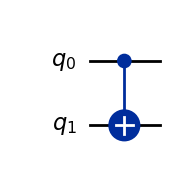

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [8]:
qc = QuantumCircuit(2)
qc.cx(0, 1)#cx(0, 1) does NOT mean “control is 0 and target is 1.” It means “qubit 0 is the control, and qubit 1 is the target.”

display(qc.draw("mpl"))
state = Statevector(qc)
print(state)

### Exercise 5:

Consider the CNOT circuit below, where **q0 is the control** and **q1 is the target**:

~~~text
q0 ──●──
     │
q1 ──X──
~~~

The initial state is:

$$
|10\rangle
$$

Before running the circuit, predict what the CNOT gate will do.

**Question:** What will be the final state after the CNOT gate?

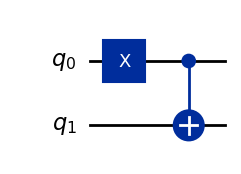

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))


In [9]:
qc = QuantumCircuit(2)
qc.x(0)       # Prepare |10>
qc.cx(0, 1)#cx(0, 1) does NOT mean “control is 0 and target is 1.” It means “qubit 0 is the control, and qubit 1 is the target.”

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)


# Control and target matter

Start with:

$$|10\rangle$$

Compare:

1. `cx(0, 1)`
2. `cx(1, 0)`

Predict both outputs before running the code.

Then explain:

> Why does changing the control qubit change the result?


q0 controls q1


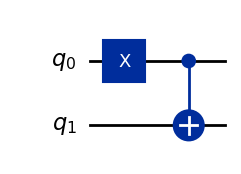

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))

q1 controls q0


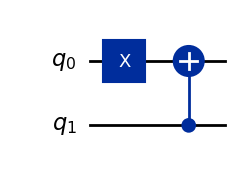

Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [10]:
# q0 controls q1
qc1 = QuantumCircuit(2)
qc1.x(0)
qc1.cx(0, 1)

# q1 controls q0
qc2 = QuantumCircuit(2)
qc2.x(0)
qc2.cx(1, 0)

print("q0 controls q1")
display(qc1.draw("mpl"))
print(Statevector(qc1))

print("\nq1 controls q0")
display(qc2.draw("mpl"))
print(Statevector(qc2))


### Exercise 6: What does this circuit do?

Look at the circuit below:

~~~text
q0 ──●────X────●──
     │    │    │
q1 ──X────●────X──
~~~

The circuit consists of **three CNOT gates** applied from left to right.

Your task:

1. Start with the state $|10\rangle$. Write the corresponding Qiskit code to implement this circuit.
2. Predict the state after each CNOT gate.
3. Run your circuit and compare your prediction with the result.

**Final question:** Based on what you observe, what operation do these three CNOT gates perform on the two qubits?


Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


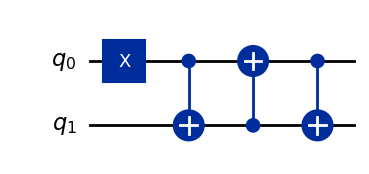

Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


In [11]:
qc = QuantumCircuit(2)

# Start with |10>
qc.x(0)
state = Statevector(qc)
print(state)
# Three CNOT gates, applied from left to right
qc.cx(0, 1)    # q0 controls q1
qc.cx(1, 0)    # q1 controls q0
qc.cx(0, 1)    # q0 controls q1

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)

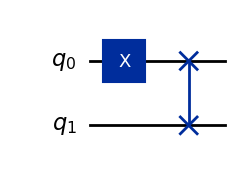

Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


In [12]:
#SWAP exchanges the states of two qubits.**

#Exercise 7: Start with: |10>. Apply SWAP and predict the result.

qc = QuantumCircuit(2)

# Prepare |10>
qc.x(0)

# Swap the qubits
qc.swap(0, 1)

display(qc.draw("mpl"))
print(Statevector(qc))


## CZ gate

The controlled-Z gate has the structure:

```text
q0 ──●──
     │
q1 ──Z──
```

Unlike CNOT, CZ does **not** flip the target.

Its important action is:
$$
|11\rangle \rightarrow -|11\rangle$$

The other computational-basis states are unchanged.

This is a first example of a gate changing **phase** rather than simply changing the computational-basis value.


### Exercise 8: CZ acting on $|11\rangle$

Prepare $|11\rangle$, apply CZ, and inspect the statevector.


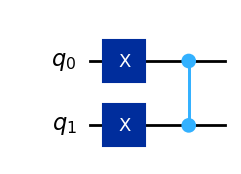

Statevector([ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
            dims=(2, 2))


In [13]:
qc = QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.cz(0, 1)

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)


## 4. Controlled versions of other gates

The same control-target idea can be applied to many gates.

Examples in Qiskit:

- `qc.ch(control, target)` — controlled-H
- `qc.crx(theta, control, target)` — controlled-\(R_x\)
- `qc.cry(theta, control, target)` — controlled-\(R_y\)
- `qc.crz(theta, control, target)` — controlled-\(R_z\)

Conceptually:

```text
control ──●──
          │
target  ──U──
```

Only the target operation changes.


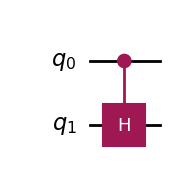

In [14]:
theta = np.pi / 2

qc = QuantumCircuit(2)
qc.ch(0, 1)

display(qc.draw("mpl"))


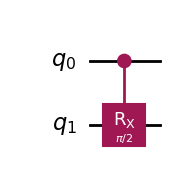

In [15]:
theta = np.pi / 2

qc = QuantumCircuit(2)
qc.crx(theta, 0, 1)

display(qc.draw("mpl"))


Circuit 1:


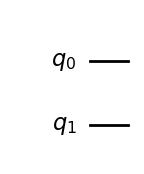

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
Circuit 2:


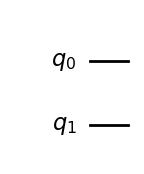

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [16]:
# First circuit: q0 controls q1
circuit_1 = QuantumCircuit(2)

# Prepare |10>
# circuit_1.x(0)
# circuit_1.cx(0, 1)

print("Circuit 1:")
display(circuit_1.draw("mpl"))
print(Statevector(circuit_1))


# Second circuit: q1 controls q0
circuit_2 = QuantumCircuit(2)

# Prepare |10>
# circuit_2.x(0)
# circuit_2.cx(1, 0)

print("Circuit 2:")
display(circuit_2.draw("mpl"))
print(Statevector(circuit_2))


## Exercise 9— Controlled-H

Compare these two circuits:

**Circuit A**

```text
q0 ──H──
```

**Circuit B**

```text
q0 ──●──
     │
q1 ──H──
```

For Circuit B:

1. What happens when q0 is 0?
2. What happens when q0 is 1?
3. Prepare both cases and inspect the statevectors.

Try to answer without running the circuit first.


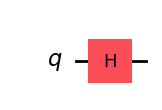

Circuit A: H gate
Statevector([0.7071+0.j, 0.7071+0.j],
            dims=(2,))
Control starts at |0>


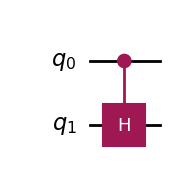

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))

Control starts at |1>


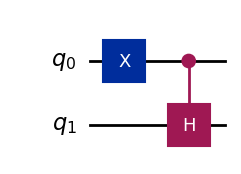

Statevector([0.    +0.j, 0.7071+0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2))


In [17]:
# Circuit A: Ordinary H gate

qcA = QuantumCircuit(1)

qcA.h(0)

display(qcA.draw("mpl"))

print("Circuit A: H gate")
print(Statevector(qcA))

# Control = 0
qc0 = QuantumCircuit(2)
qc0.ch(0, 1)

print("Control starts at |0>")
display(qc0.draw("mpl"))
print(Statevector(qc0))

# Control = 1
qc1 = QuantumCircuit(2)
qc1.x(0)
qc1.ch(0, 1)

print("\nControl starts at |1>")
display(qc1.draw("mpl"))
print(Statevector(qc1))


# 5. H + CNOT: the most important circuit combination

Consider:

```text
q0 ──H──●──
        │
q1 ─────X──
```

Starting from $|00\rangle$:

$|00\rangle
\xrightarrow{H\text{ on }q_0}
\frac{|00\rangle+|10\rangle}{\sqrt2}
$

Then CNOT gives:

$\frac{|00\rangle+|11\rangle}{\sqrt2}.
$

This is a Bell state.
A useful conceptual distinction:

- **H creates superposition.**
- **CNOT can create correlations/entanglement when acting on an appropriate superposition.**
- H by itself does not entangle separate qubits.

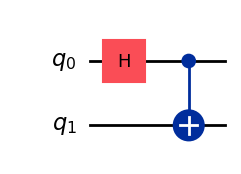

Statevector([0.7071+0.j, 0.    +0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2))


In [18]:
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)

## Exercise 10 — Superposition on two qubits. Apply H on both qubits, then CNOT
CNOT between superposition states
Consider:

```text
q0 ──H────●──
          │
q1 ──H────X──
```

Starting from $|00\rangle$,
predict the final state? Verify using Qiskit.


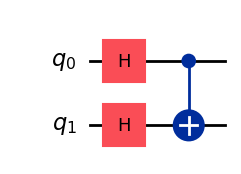

Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


In [19]:
qc = QuantumCircuit(2)

qc.h(0)
qc.h(1)
qc.cx(0, 1)

display(qc.draw("mpl"))
print(Statevector(qc))


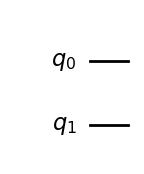

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [20]:
qc = QuantumCircuit(2)

# Apply H to both qubits
# qc.h(0)
# qc.h(1)

display(qc.draw("mpl"))
print(Statevector(qc))


## Exercise 11  — A CNOT can be undone

Consider:

```text
q0 ──●────●──
     │    │
q1 ──X────X──
```

Starting from an arbitrary two-qubit state, what will be the output?

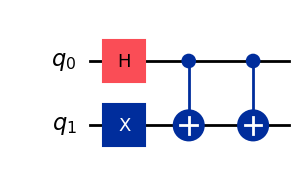

Statevector([0.    +0.j, 0.    +0.j, 0.7071+0.j, 0.7071+0.j],
            dims=(2, 2))


In [21]:
qc = QuantumCircuit(2)

qc.x(0)
qc.cx(0, 1)
qc.cx(0, 1)

display(qc.draw("mpl"))
print(Statevector(qc))


## Exercise 12: Build the four Bell states

The four Bell states are:

$
|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt2}
$

$|\Phi^-\rangle=\frac{|00\rangle-|11\rangle}{\sqrt2}
$

$
|\Psi^+\rangle=\frac{|01\rangle+|10\rangle}{\sqrt2}
$

$
|\Psi^-\rangle=\frac{|01\rangle-|10\rangle}{\sqrt2}.
$

Starting from $|00\rangle$, construct all four using H, X, Z, and CNOT.


# Circuit variation challenge set

These are intended to be solved **before running the corresponding code**.

### H before CNOT

```text
q0 ──H──●──
        │
q1 ─────X──
```
You have alreday seen the first bell state.

---
Starting from $|00\rangle$, find the final state for all of the circuits below:

### Challenge 1 —

```text
q0 ──H──●──Z──
        │
q1 ─────X─────
```

---

### Challenge 2 —  

```text
q0 ──H──●────
        │
q1 ─────X──X─
```

Find the final state.

---

### Challenge 3 —  

```text
q0 ──H──●────Z──
        │
q1 ─────X──X───
```

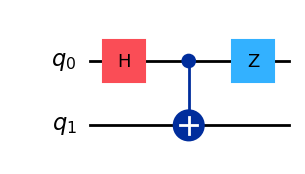

Statevector([ 0.7071+0.j, -0.    +0.j,  0.    +0.j, -0.7071+0.j],
            dims=(2, 2))


In [ ]:
#Phi-
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.z(0)

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)

In [ ]:
# Psi+ Bell state

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.x(1)

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)

In [ ]:
# Psi- Bell state

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)

## Exercise 13— Create a GHZ state
A Bell state shows us that two qubits can become entangled. A GHZ (Greenberger–Horne–Zeilinger) state takes this idea to three or more qubits. The remarkable thing is that the three qubits behave as one correlated quantum system: they are in a superposition of all 0 and all 1. Multi-qubit entangled states such as GHZ states appear in areas including quantum communication, distributed quantum computing, and some quantum error-correction and sensing schemes.
Construct the three-qubit GHZ state:

$
|GHZ\rangle =
\frac{|000\rangle+|111\rangle}{\sqrt2}.
$

Requirements:

- Start from $|000\rangle$.
- Use one H gate.
- Use two CNOT gates.
- Print the circuit.
- Print the final statevector.
- Explain in one or two sentences how the first CNOT and second CNOT extend the correlation.


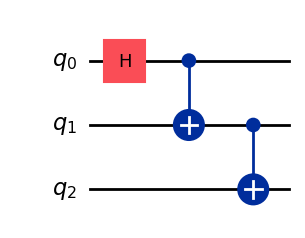

Statevector([0.7071+0.j, 0.    +0.j, 0.    +0.j, 0.    +0.j, 0.    +0.j,
             0.    +0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2, 2))


In [ ]:
qc = QuantumCircuit(3)

qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

display(qc.draw("mpl"))

state = Statevector(qc)
print(state)

# Quick summary: What have you learned?

You have now built several different types of quantum circuits:

| Circuit idea | Main concept |
|---|---|
| X circuit | Bit flip |
| H circuit | Superposition |
| CNOT circuit | Conditional operation |
| CZ circuit | Controlled phase |
| SWAP circuit | Moving quantum information |
| H + CNOT | Entanglement |

The goal is not to memorize the circuits.

The goal is to develop the habit of looking at a circuit and asking:

1. **What is the input state?**
2. **What does each gate do?**
3. **What is the state after each step?**
4. **What should I expect at the end?**
5. **Can Qiskit verify my prediction?**

> **Predict → Implement → Visualize → Verify → Explain**
